# Feature Engineering - Elo Delta

This notebook evaluates different window sizes for Elo delta calculation to find the optimal window size for improving prediction accuracy.

## Approach

1. Calculate Elo deltas for each team using different window sizes
2. Test different weights for incorporating the delta into win probability predictions
3. Evaluate using Brier score to find the best combination
4. Save the results with the optimal window size

In [1]:
import sys

sys.path.insert(0, "..")

In [22]:
from itertools import product

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.evaluation.brier_score import brier_score
from src.features.elo import predict_win
from src.features.elo_window import calculate_elo_window_delta
from src.utils.constants import Columns
from src.utils.paths import get_data_directory

# Elo Window Delta Evaluation

Evaluate different window sizes for Elo delta calculation to find the optimal window size.

In [37]:
ELO_RESULT_NAME = "OverallCompactResultsWithELO"

In [ ]:
m_results_w_elo = pd.read_csv(get_data_directory() / f"M{ELO_RESULT_NAME}.csv")
w_results_w_elo = pd.read_csv(get_data_directory() / f"W{ELO_RESULT_NAME}.csv")

In [5]:
m_results_w_elo.head(5)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WElo,LElo
0,1985,20,1228,81,1328,64,N,0,1000.0,1000.0
1,1985,25,1106,77,1354,70,H,0,1000.0,1000.0
2,1985,25,1112,63,1223,56,H,0,1000.0,1000.0
3,1985,25,1165,70,1432,54,H,0,1000.0,1000.0
4,1985,25,1192,86,1447,74,H,0,1000.0,1000.0


In [6]:
w_results_w_elo.head(5)

,Season,DayNum,WTeamID,WScore,LTeamID,LScore,WLoc,NumOT,WElo,LElo
0,1998,18,3104,91,3202,41,H,0,1000.0,1000.0
1,1998,18,3163,87,3221,76,H,0,1000.0,1000.0
2,1998,18,3222,66,3261,59,H,0,1000.0,1000.0
3,1998,18,3307,69,3365,62,H,0,1000.0,1000.0
4,1998,18,3349,115,3411,35,H,0,1000.0,1000.0


In [40]:
window_sizes = [1, 2, 3, 5, 7, 10, 15]
reset_between_seasons = [True, False]
elo_delta_weights = np.linspace(0, 0.3, 20)

In [41]:
def calculate_win_probability(w_elo, l_elo, w_delta, l_delta, delta_weight=0.1):
    adjusted_elo_w = w_elo + delta_weight * w_delta
    adjusted_elo_l = l_elo + delta_weight * l_delta
    return predict_win(adjusted_elo_w, adjusted_elo_l)

In [42]:
def grid_search(
    results_w_elo: pd.DataFrame,
    window_sizes: list[int],
    reset_between_seasons: list[bool],
    elo_delta_weights: list[float],
):
    results = []
    for window_size, r in product(window_sizes, reset_between_seasons):
        print(f"Evaluating window size {window_size}{', reset between seasons' if r else ''}:")

        results_with_delta = calculate_elo_window_delta(results_w_elo, window_size=window_size, reset_between_seasons=r)

        base_probs = predict_win(results_with_delta[Columns.WELO].values, results_with_delta[Columns.LELO].values)
        base_brier = brier_score(np.ones(len(base_probs)), base_probs)

        for elo_delta_weight in elo_delta_weights:
            probs = calculate_win_probability(
                results_with_delta[Columns.WELO].values,
                results_with_delta[Columns.LELO].values,
                results_with_delta[Columns.WELO_DELTA].values,
                results_with_delta[Columns.LELO_DELTA].values,
                delta_weight=elo_delta_weight,
            )

            delta_brier = brier_score(np.ones(len(probs)), probs)

            results.append(
                {
                    "window_size": window_size,
                    "reset_between_seasons": r,
                    "base_brier": base_brier,
                    "delta_brier": delta_brier,
                    "delta_weight": elo_delta_weight,
                    "improvement": base_brier - delta_brier,
                }
            )

            print(f"  Base Brier: {base_brier:.6f}")
            print(f"  Delta Brier: {delta_brier:.6f} (weight={elo_delta_weight:.3f})")
            print(f"  Improvement: {base_brier - delta_brier:.6f}")
            print()

    return results

In [43]:
results = grid_search(
    m_results_w_elo,
    window_sizes=window_sizes,
    reset_between_seasons=reset_between_seasons,
    elo_delta_weights=elo_delta_weights,
)

Evaluating window size 1, reset between seasons:
  Base Brier: 0.191071
  Delta Brier: 0.191071 (weight=0.000)
  Improvement: 0.000000

  Base Brier: 0.191071
  Delta Brier: 0.191066 (weight=0.016)
  Improvement: 0.000004

  Base Brier: 0.191071
  Delta Brier: 0.191062 (weight=0.032)
  Improvement: 0.000008

  Base Brier: 0.191071
  Delta Brier: 0.191059 (weight=0.047)
  Improvement: 0.000012

  Base Brier: 0.191071
  Delta Brier: 0.191056 (weight=0.063)
  Improvement: 0.000014

  Base Brier: 0.191071
  Delta Brier: 0.191054 (weight=0.079)
  Improvement: 0.000017

  Base Brier: 0.191071
  Delta Brier: 0.191052 (weight=0.095)
  Improvement: 0.000019

  Base Brier: 0.191071
  Delta Brier: 0.191051 (weight=0.111)
  Improvement: 0.000020

  Base Brier: 0.191071
  Delta Brier: 0.191050 (weight=0.126)
  Improvement: 0.000021

  Base Brier: 0.191071
  Delta Brier: 0.191049 (weight=0.142)
  Improvement: 0.000021

  Base Brier: 0.191071
  Delta Brier: 0.191049 (weight=0.158)
  Improvement: 0.00

In [44]:
results_df = pd.DataFrame(results)
results_df

,window_size,reset_between_seasons,base_brier,delta_brier,delta_weight,improvement
0,1,True,0.191071,0.191071,0.000000,0.000000
1,1,True,0.191071,0.191066,0.015789,0.000004
2,1,True,0.191071,0.191062,0.031579,0.000008
3,1,True,0.191071,0.191059,0.047368,0.000012
4,1,True,0.191071,0.191056,0.063158,0.000014
...,...,...,...,...,...,...
275,15,False,0.191071,0.191944,0.236842,-0.000873
276,15,False,0.191071,0.192060,0.252632,-0.000990
277,15,False,0.191071,0.192184,0.268421,-0.001113
278,15,False,0.191071,0.192315,0.284211,-0.001244


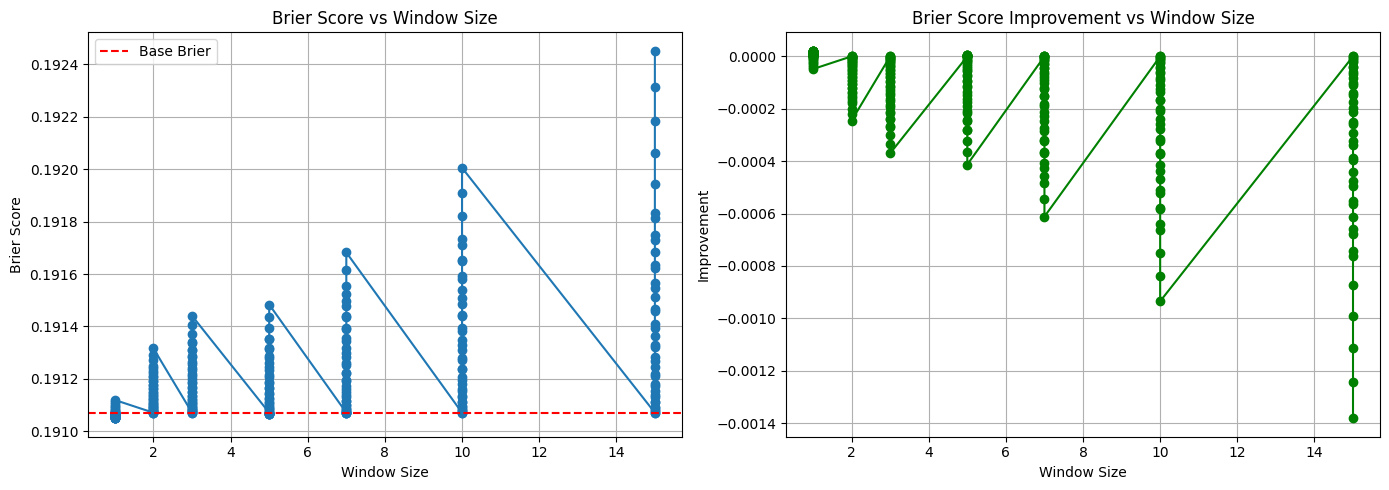

In [45]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(results_df["window_size"], results_df["delta_brier"], marker="o")
ax1.axhline(y=results_df["base_brier"].iloc[0], color="r", linestyle="--", label="Base Brier")
ax1.set_xlabel("Window Size")
ax1.set_ylabel("Brier Score")
ax1.set_title("Brier Score vs Window Size")
ax1.legend()
ax1.grid(True)

ax2.plot(results_df["window_size"], results_df["improvement"], marker="o", color="green")
ax2.set_xlabel("Window Size")
ax2.set_ylabel("Improvement")
ax2.set_title("Brier Score Improvement vs Window Size")
ax2.grid(True)

plt.tight_layout()
plt.show()

In [46]:
best_row = results_df.loc[results_df["delta_brier"].idxmin()]
print(f"Best window size: {int(best_row['window_size'])}")
print(f"Best weight: {best_row['delta_weight']:.4f}")
print(f"Brier score: {best_row['delta_brier']:.6f}")
print(f"Improvement over base: {best_row['improvement']:.6f}")

Best window size: 1
Best weight: 0.1421
Brier score: 0.191049
Improvement over base: 0.000021


In [61]:
best_window = int(best_row["window_size"])
best_reset_between_seasons = bool(best_row["reset_between_seasons"])
best_weight = float(best_row["delta_weight"])

In [60]:
m_elo_delta = calculate_elo_window_delta(
    m_results_w_elo, window_size=best_window, reset_between_seasons=reset_between_seasons
)

output_path = (
    get_data_directory()
    / f"M{ELO_RESULT_NAME}Delta{best_window}{'_Reset' if best_reset_between_seasons else ''}_{best_weight:.2f}.csv"
)
m_elo_delta.to_csv(output_path, index=False)
print(f"Saved results with best window size to {output_path}")

Saved results with best window size to C:\Users\kybur\Repos\HSLU\aicomp\code\data\MOverallCompactResultsWithELODelta1_Reset_0.14.csv


In [62]:
w_elo_delta = calculate_elo_window_delta(w_results_w_elo, window_size=best_window)

output_path = (
    get_data_directory()
    / f"W{ELO_RESULT_NAME}Delta{best_window}{'_Reset' if best_reset_between_seasons else ''}_{best_weight:.2f}.csv"
)
w_elo_delta.to_csv(output_path, index=False)
print(f"Saved results with best window size to {output_path}")

Saved results with best window size to C:\Users\kybur\Repos\HSLU\aicomp\code\data\WOverallCompactResultsWithELODelta1_Reset_0.14.csv


In [63]:
arbitrary_window = 3
arbitrary_reset_between_seasons = True
arbitrary_weight = 0.1

In [64]:
m_elo_delta = calculate_elo_window_delta(
    m_results_w_elo, window_size=arbitrary_window, reset_between_seasons=arbitrary_reset_between_seasons
)

output_path = (
    get_data_directory()
    / f"M{ELO_RESULT_NAME}Delta{arbitrary_window}{'_Reset' if arbitrary_reset_between_seasons else ''}.csv"
)
m_elo_delta.to_csv(output_path, index=False)
print(f"Saved results with best window size to {output_path}")

Saved results with best window size to C:\Users\kybur\Repos\HSLU\aicomp\code\data\MOverallCompactResultsWithELODelta3_Reset.csv


In [65]:
w_elo_delta = calculate_elo_window_delta(w_results_w_elo, window_size=arbitrary_window)

output_path = (
    get_data_directory()
    / f"W{ELO_RESULT_NAME}Delta{arbitrary_window}{'_Reset' if arbitrary_reset_between_seasons else ''}.csv"
)
w_elo_delta.to_csv(output_path, index=False)
print(f"Saved results with best window size to {output_path}")

Saved results with best window size to C:\Users\kybur\Repos\HSLU\aicomp\code\data\WOverallCompactResultsWithELODelta3_Reset.csv
